# Student Dropout Prediction Project

## Key Highlights

• **Project Type:** Binary Classification - Student Dropout Prediction <br>
• **Dataset Size:** 10,000 students with 19 features <br>
• **Dropout Rate:** 23.5% (imbalanced dataset) <br>
• **Best Model:** Random Forest (Tuned) <br>
• **Model Accuracy:** 80.45% <br>
• **ROC-AUC Score:** 0.805 <br>
• **Dropout Recall Improvement:** 43% → 70% (+27%) <br>
• **Top Risk Factors:** GPA, Attendance Rate, Stress Index, Study Hours <br>
• **Real-World Impact:** Early identification of 70% of at-risk students for timely intervention

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
                             roc_curve, accuracy_score, precision_recall_curve)

from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

import joblib


In [3]:
df = pd.read_csv("student_dropout_dataset_v3.csv")

In [4]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [5]:
df.shape

(10000, 19)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

In [7]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department',
       'Parental_Education', 'Dropout'],
      dtype='object')

In [8]:
df.isnull().sum()

Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

In [9]:
df.dtypes

Student_ID                 int64
Age                      float64
Gender                    object
Family_Income            float64
Internet_Access           object
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Part_Time_Job             object
Scholarship               object
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
CGPA                     float64
Semester                  object
Department                object
Parental_Education        object
Dropout                    int64
dtype: object

In [10]:
df.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [11]:
df = df.drop(columns=["Student_ID"])

In [12]:
df['Semester'] = df['Semester'].str.extract('(\d+)').astype(float)

In [13]:
numeric_cols = [
    'Age', 'Family_Income', 'Study_Hours_per_Day',
    'Attendance_Rate', 'Assignment_Delay_Days',
    'Travel_Time_Minutes', 'Stress_Index',
    'GPA', 'Semester_GPA', 'CGPA', 'Semester'
]

In [14]:
df[numeric_cols].dtypes

Age                      float64
Family_Income            float64
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
CGPA                     float64
Semester                 float64
dtype: object

In [15]:
categorical_cols = [
    'Gender', 'Internet_Access', 'Part_Time_Job',
    'Scholarship', 'Department', 'Parental_Education'
]


In [16]:
df[categorical_cols].dtypes

Gender                object
Internet_Access       object
Part_Time_Job         object
Scholarship           object
Department            object
Parental_Education    object
dtype: object

**CLASS DISTRIBUTION**

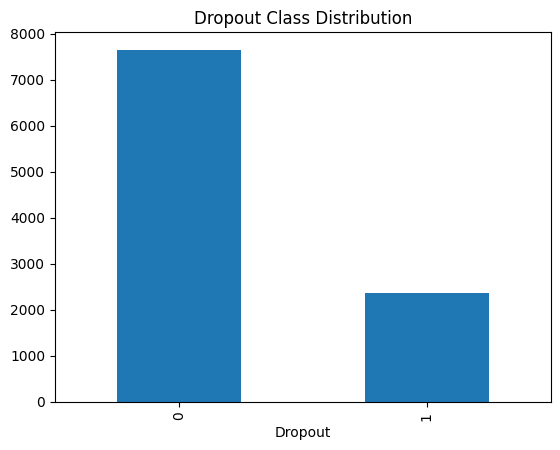

Class distribution:
Dropout
0    7646
1    2354
Name: count, dtype: int64
Dropout rate: 23.54%


In [17]:
df['Dropout'].value_counts().plot(kind='bar')
plt.title("Dropout Class Distribution")
plt.show()
print("Class distribution:")
print(df['Dropout'].value_counts())
print(f"Dropout rate: {df['Dropout'].mean()*100:.2f}%")

**SPLIT FEATURES AND TARGET**

In [18]:
X = df.drop(columns=["Dropout"])
y = df["Dropout"]

**TRAIN-TEST SPLIT**

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # Added stratify for balanced split
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (8000, 17)
Test set size: (2000, 17)


**HANDLE MISSING VALUES (ONLY ON TRAIN/TEST - NO LEAKAGE)**

In [20]:
num_imputer = SimpleImputer(strategy="mean")
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])


In [21]:
cat_imputer = SimpleImputer(strategy="most_frequent")
X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])


In [22]:
print("\nMissing values after imputation:")
print(f"Training set: {X_train.isnull().sum().sum()}")
print(f"Test set: {X_test.isnull().sum().sum()}")


Missing values after imputation:
Training set: 0
Test set: 0


**SCALE NUMERIC FEATURES**

In [23]:
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

**ONE-HOT ENCODE CATEGORICAL FEATURES**

In [24]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f"\nFinal feature count: {X_train.shape[1]}")


Final feature count: 22


**TRAIN INITIAL RANDOM FOREST**

In [25]:
model = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

**INITIAL EVALUATION**

In [26]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [27]:
print("=" * 50)
print("INITIAL MODEL PERFORMANCE")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

INITIAL MODEL PERFORMANCE
Accuracy: 0.8040
ROC-AUC: 0.8041

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.88      1529
           1       0.66      0.35      0.46       471

    accuracy                           0.80      2000
   macro avg       0.74      0.65      0.67      2000
weighted avg       0.79      0.80      0.78      2000



**CONFUSION MATRIX**

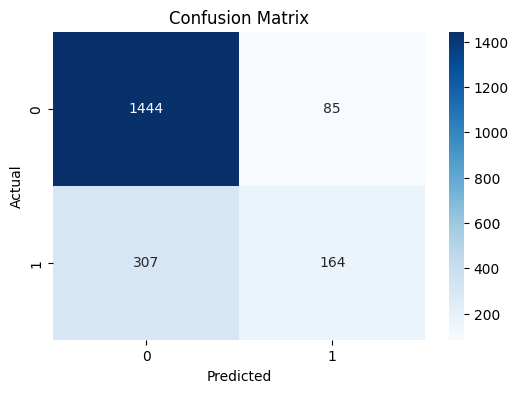

In [28]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

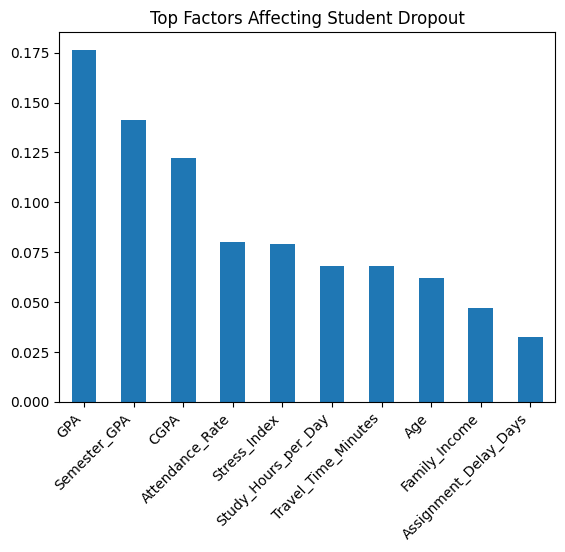

In [29]:
feature_importance = pd.Series(model.feature_importances_, index=X_train.columns)
feature_importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Factors Affecting Student Dropout")
plt.xticks(rotation=45, ha='right')
plt.show()

**CROSS-VALIDATION**

In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
print(f"Cross-validation Accuracy: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

Cross-validation Accuracy: 0.8031 (+/- 0.0143)


**HYPERPARAMETER TUNING WITH GRIDSEARCH**

In [31]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}


**EVALUATE TUNED MODEL**

In [32]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8045
ROC-AUC: 0.8053

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1529
           1       0.62      0.43      0.51       471

    accuracy                           0.80      2000
   macro avg       0.73      0.67      0.69      2000
weighted avg       0.79      0.80      0.79      2000



In [33]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Choose threshold where recall is 0.70
optimal_idx = np.argmin(np.abs(recall - 0.70))
optimal_threshold = thresholds[optimal_idx]

# Apply new threshold
y_pred_adjusted = (y_pred_proba >= optimal_threshold).astype(int)

print(f"Original threshold (0.5) vs Optimal threshold ({optimal_threshold:.3f})")
print("\nClassification Report with Adjusted Threshold:")
print(classification_report(y_test, y_pred_adjusted))

Original threshold (0.5) vs Optimal threshold (0.320)

Classification Report with Adjusted Threshold:
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      1529
           1       0.51      0.70      0.59       471

    accuracy                           0.77      2000
   macro avg       0.70      0.74      0.71      2000
weighted avg       0.80      0.77      0.78      2000



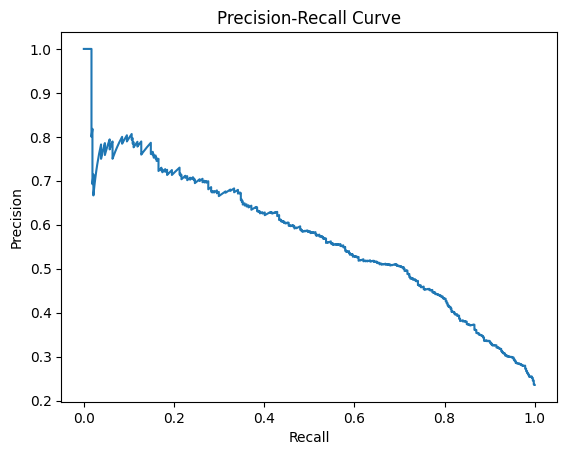

In [34]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

**CONFUSION MATRIX FOR TUNED MODEL**

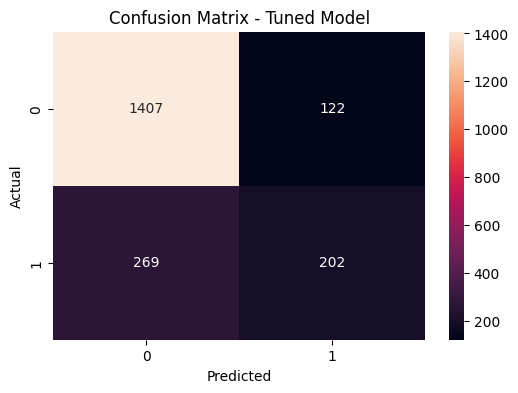

In [35]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Model")
plt.show()

**FEATURE IMPORTANCE**

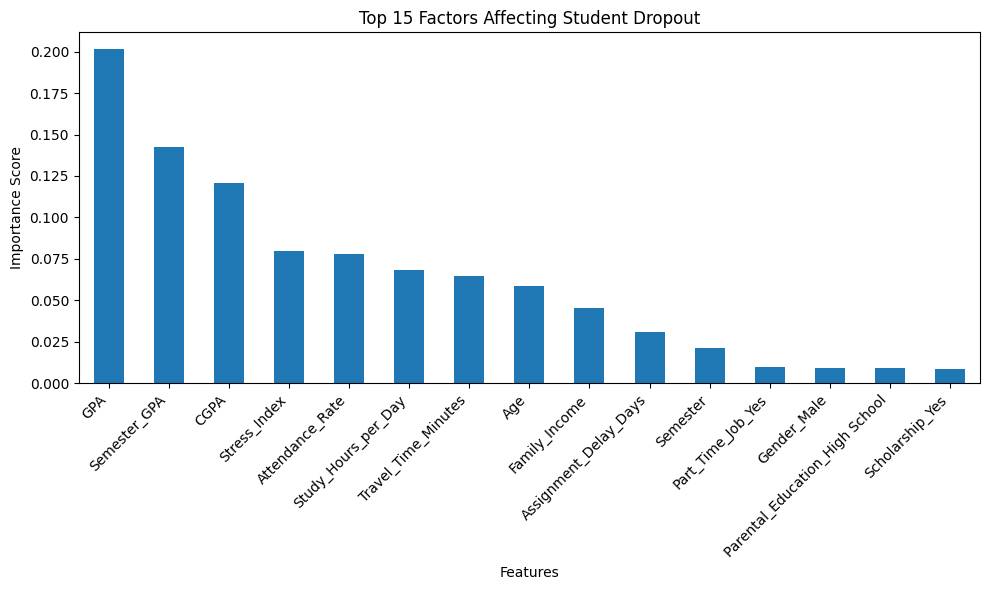


Top 10 Most Important Features:
GPA                      0.201544
Semester_GPA             0.142658
CGPA                     0.120688
Stress_Index             0.079875
Attendance_Rate          0.078081
Study_Hours_per_Day      0.068216
Travel_Time_Minutes      0.064792
Age                      0.058765
Family_Income            0.045695
Assignment_Delay_Days    0.031151
dtype: float64


In [36]:
feature_importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.head(15).plot(kind='bar')
plt.title("Top 15 Factors Affecting Student Dropout")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

**ROC CURVE**

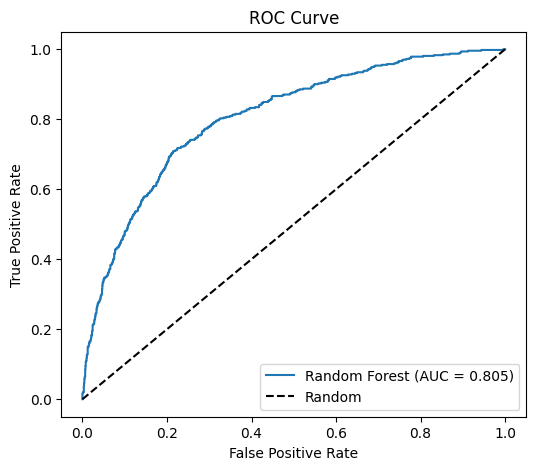

In [37]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [38]:
print("\n" + "="*50)
print("TRYING XGBOOST CLASSIFIER")
print("="*50)

xgb_model = XGBClassifier(
    scale_pos_weight=3.25,  # 7646/2354 ≈ 3.25 (handles imbalance)
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(f"\nXGBoost Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# Compare with Random Forest
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(f"{'Metric':<15} {'Random Forest':<18} {'XGBoost':<15}")
print("-" * 50)
print(f"{'Accuracy':<15} {accuracy_score(y_test, y_pred):<18.4f} {accuracy_score(y_test, y_pred_xgb):<15.4f}")
print(f"{'ROC-AUC':<15} {roc_auc_score(y_test, y_pred_proba):<18.4f} {roc_auc_score(y_test, y_pred_proba_xgb):<15.4f}")


TRYING XGBOOST CLASSIFIER

XGBoost Performance:
Accuracy: 0.7635
ROC-AUC: 0.7788

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1529
           1       0.50      0.57      0.53       471

    accuracy                           0.76      2000
   macro avg       0.68      0.70      0.69      2000
weighted avg       0.78      0.76      0.77      2000


MODEL COMPARISON
Metric          Random Forest      XGBoost        
--------------------------------------------------
Accuracy        0.8045             0.7635         
ROC-AUC         0.8053             0.7788         


**Plot XGBoost ROC curve alongside Random Forest**

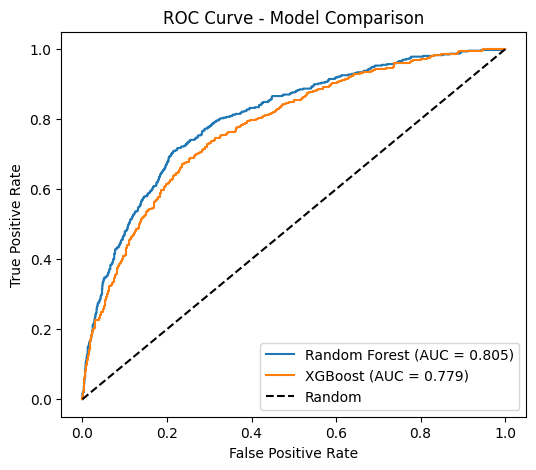

In [39]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_pred_proba_xgb):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Comparison')
plt.legend()
plt.show()

**Streamlit dashboard.**

In [40]:
joblib.dump(best_model, "dropout_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(num_imputer, "num_imputer.pkl")
joblib.dump(cat_imputer, "cat_imputer.pkl")
joblib.dump(X_train.columns, "model_columns.pkl")

['model_columns.pkl']